# SHAP Explanations for STDNN-SE Tox21 Models
This notebook demonstrates how to apply SHAP to the PyTorch STDNN models trained on Tox21. It covers loading the model, preparing embeddings, applying SHAP for both positive and negative classes, generating summary and local explanations, and visualizing the results.

In [2]:
# Import required libraries
import torch
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import shap

# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
# Load SMILES embeddings and Tox21 data
smiles_embed = torch.load("../data/smiles_embedding/toxicity_smiles.pt")
tox21_file = '../data/datasets/tox21/raw_data/tox21.csv'
tox21_tasks = ['NR-AR', 'NR-Aromatase', 'NR-PPAR-gamma', 'SR-HSE',
               'NR-AR-LBD', 'NR-ER', 'SR-ARE', 'SR-MMP',
               'NR-AhR', 'NR-ER-LBD', 'SR-ATAD5', 'SR-p53']
data = pd.read_csv(tox21_file)
# Add SMILES embeddings to dataframe
data['smiles_embed'] = data['smiles'].apply(lambda x: smiles_embed.get(x))
data = data.dropna(subset=['smiles_embed']).reset_index(drop=True)
X = np.stack(data['smiles_embed'].values)
Y = data[tox21_tasks].values

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [4]:
# Define the DNN model class (must match training)
import torch.nn as nn

class DNN(nn.Module):
    def __init__(self, input_shape, all_tasks):
        super(DNN, self).__init__()
        self.hidden_1 = nn.ModuleList([nn.Linear(input_shape, 1024) for _ in all_tasks])
        self.batchnorm_1 = nn.ModuleList([nn.BatchNorm1d(1024) for _ in all_tasks])
        self.hidden_2 = nn.ModuleList([nn.Linear(1024, 512) for _ in all_tasks])
        self.batchnorm_2 = nn.ModuleList([nn.BatchNorm1d(512) for _ in all_tasks])
        self.output = nn.ModuleList([nn.Linear(512, 1) for _ in all_tasks])
        self.leakyReLU = nn.LeakyReLU(0.05)
    def forward(self, x):
        x_task = [None for _ in range(len(self.output))]
        for task in range(len(self.output)):
            x_task[task] = self.hidden_1[task](x)
            x_task[task] = self.batchnorm_1[task](x_task[task])
            x_task[task] = self.leakyReLU(x_task[task])
            x_task[task] = self.hidden_2[task](x_task[task])
            x_task[task] = self.batchnorm_2[task](x_task[task])
            x_task[task] = self.leakyReLU(x_task[task])
            x_task[task] = self.output[task](x_task[task])
            x_task[task] = torch.sigmoid(x_task[task])
        return x_task

In [5]:
# Load a trained model for a specific task (e.g., 'NR-AR')
input_shape = X.shape[1]
all_tasks = tox21_tasks
selected_task = 1  # Index of the task to explain (e.g., 0 for 'NR-AR')
model = DNN(input_shape, all_tasks).to(device)
model_path = f"../deep_predictive_models/deep_learning/SE/STDNN/trained_models/STDNN_SE_tox21_seed124/model_{all_tasks[selected_task]}_pw20.0.pt"  # Adjust pos_weight if needed
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

def model_predict(x):
    x_tensor = torch.tensor(x, dtype=torch.float32).to(device)
    with torch.no_grad():
        out = model(x_tensor)
        return out[selected_task].cpu().numpy()

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [6]:
class SingleTaskModel(torch.nn.Module):
    def __init__(self, base_model, task_idx):
        super().__init__()
        self.base_model = base_model
        self.task_idx = task_idx
    def forward(self, x):
        return self.base_model(x)[self.task_idx]

# Select a background dataset for SHAP (e.g., 100 random samples)
wrapped_model = SingleTaskModel(model, selected_task)

background = X[np.random.choice(X.shape[0], 100, replace=False)]

def model_fn(x):
    x_tensor = torch.tensor(x, dtype=torch.float32).to(device)
    with torch.no_grad():
        out = wrapped_model(x_tensor)
    return out.cpu().numpy()

explainer = shap.KernelExplainer(model_fn, background)

sample_idx = np.arange(100)
shap_values = explainer.shap_values(X[sample_idx])


  0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

## SHAP Summary Plot
Visualize the global feature importance for the selected task using a summary plot.

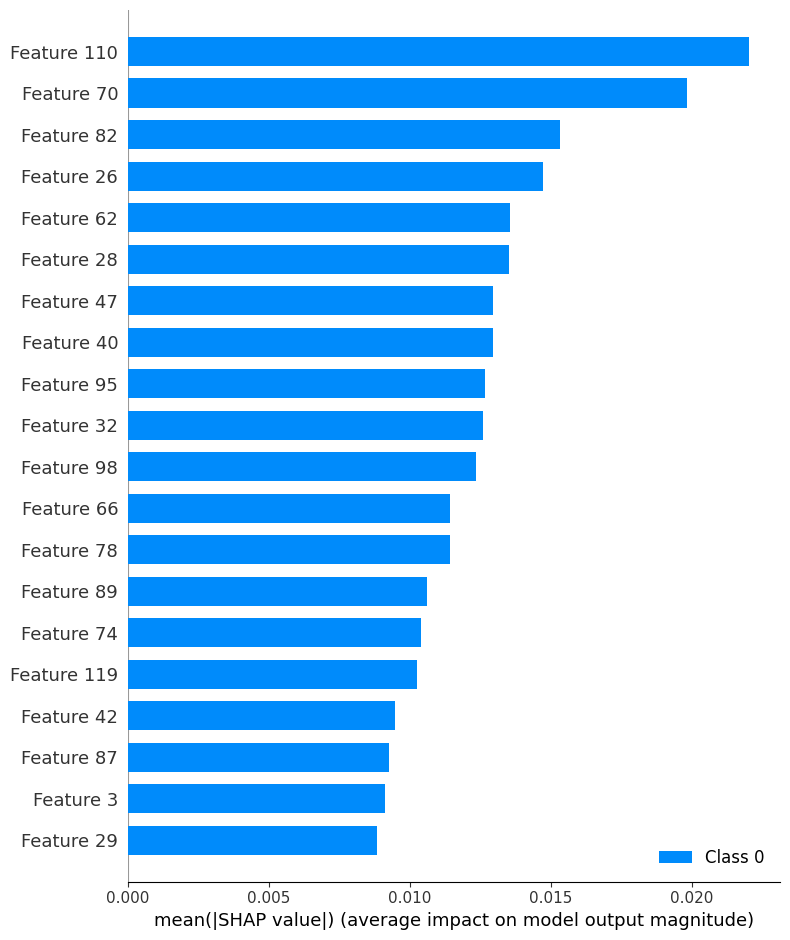

In [ ]:
# SHAP summary plot for the selected task (positive class)
shap.summary_plot(shap_values, X[sample_idx], show=True)
plt.show() 

## SHAP Local Explanations
Visualize local explanations for individual samples (both positive and negative classes).

No positive samples in the selected subset.


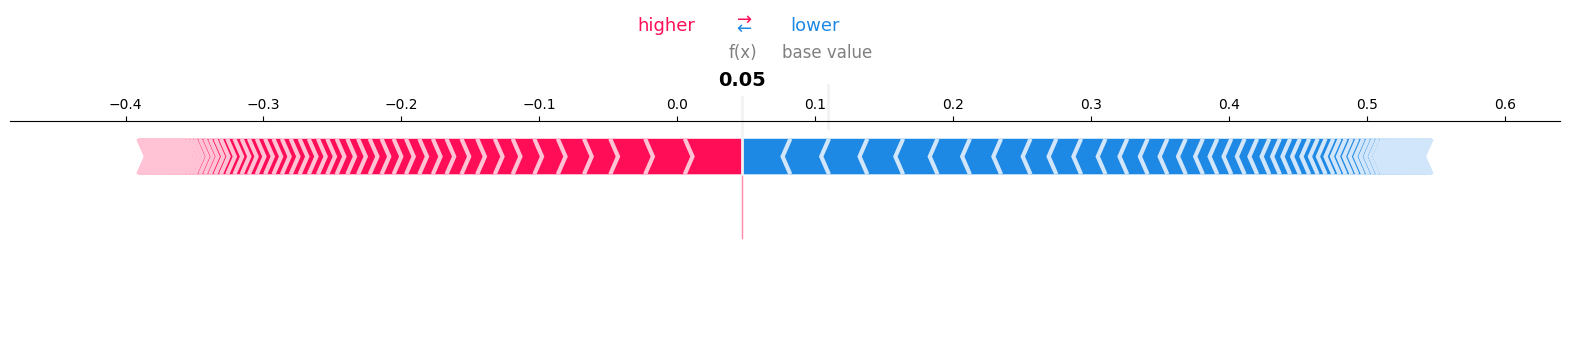

In [ ]:
# Find indices for positive and negative class examples
positive_idx = np.where(Y[sample_idx, selected_task] == 1)[0]
negative_idx = np.where(Y[sample_idx, selected_task] == 0)[0]

# Local explanation for a positive sample
if len(positive_idx) > 0:
    shap.force_plot(explainer.expected_value[0], shap_values[0][positive_idx[0]], X[sample_idx][positive_idx[0]], matplotlib=True)
    plt.show()
else:
    print("No positive samples in the selected subset.")

# Local explanation for a negative sample
if len(negative_idx) > 0:
    shap.force_plot(explainer.expected_value[0], shap_values[0][negative_idx[0]], X[sample_idx][negative_idx[0]], matplotlib=True)
    plt.show()
else:
    print("No negative samples in the selected subset.")